In [1]:
STUDENT_NAME = "Drashti Shah"
FULL_SID = "013852046"
SID4 = 2046
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10
TRAINING_SEEDS = [SEED, SEED + 1, SEED + 2]

BASELINE_CONFIG = {"name": "Baseline", "hidden_layers": [64, 32], "learning_rate": 0.001, "epochs": 30, "batch_size": 32}
MODIFIED_CONFIG = {"name": "Modified (HP_ID 0)", "hidden_layers": [32], "learning_rate": 0.001, "epochs": 30, "batch_size": 32}

assert (SID4, SEED, SLICE, HP_ID, CLS_A, CLS_B) == (2046, 2046, 46, 0, 6, 3)

print(f"Student: {STUDENT_NAME}")
print(f"Full Student ID: {FULL_SID}")
print(f"SID4  = {SID4}")
print(f"SEED  = {SEED}")
print(f"SLICE = {SLICE}")
print(f"HP_ID = {HP_ID}")
print(f"CLS_A = {CLS_A}")
print(f"CLS_B = {CLS_B}")
print(f"Training seeds = {TRAINING_SEEDS}")
print(f"Baseline configuration = {BASELINE_CONFIG}")
print(f"Modified configuration = {MODIFIED_CONFIG}")

Student: Drashti Shah
Full Student ID: 013852046
SID4  = 2046
SEED  = 2046
SLICE = 46
HP_ID = 0
CLS_A = 6
CLS_B = 3
Training seeds = [2046, 2047, 2048]
Baseline configuration = {'name': 'Baseline', 'hidden_layers': [64, 32], 'learning_rate': 0.001, 'epochs': 30, 'batch_size': 32}
Modified configuration = {'name': 'Modified (HP_ID 0)', 'hidden_layers': [32], 'learning_rate': 0.001, 'epochs': 30, 'batch_size': 32}


In [2]:
import os
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random, platform, json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import tensorflow as tf

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)
RUN_LOG = Path("RUN_LOG.txt")

def log(section, message):
    stamp = datetime.now(timezone.utc).isoformat()
    with RUN_LOG.open("a", encoding="utf-8") as f:
        f.write(f"[{stamp}] [{section}] {message}\n")

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    tf.keras.utils.set_random_seed(seed)

set_all_seeds(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    print(f"Could not enable TensorFlow deterministic ops: {exc}")

version_info = (
    f"Python {platform.python_version()} | NumPy {np.__version__} | "
    f"pandas {pd.__version__} | PyTorch {torch.__version__} | TensorFlow {tf.__version__}"
)
print(version_info)
print("PyTorch CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("PyTorch device:", torch.cuda.get_device_name(0))
print("TensorFlow visible devices:", tf.config.list_physical_devices())

log("NEURAL NETWORK SECTION START", version_info)

Python 3.13.15 | NumPy 2.1.3 | pandas 2.2.3 | PyTorch 2.11.0+cu128 | TensorFlow 2.20.0
PyTorch CUDA available: True
PyTorch device: Tesla T4
TensorFlow visible devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

candidate_paths = [Path("diabetes.csv"), Path("/content/diabetes.csv"), Path("/content/sample_data/diabetes.csv")]
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("diabetes.csv not found. Upload it next to this notebook (or to /content) first.")

df = pd.read_csv(data_path, header=None, names=columns)

print(f"Loaded from: {data_path}")
print(f"Shape: {df.shape}")
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", int(df.duplicated().sum()))
print("\nClass distribution (Outcome):")
print(df["Outcome"].value_counts().sort_index())
print("\nDescriptive statistics:")
display(df.describe())
print("\nSample rows:")
display(df.head(10))

log("NEURAL NETWORK SECTION", f"Loaded dataset from {data_path}, shape={df.shape}")

Loaded from: /content/sample_data/diabetes.csv
Shape: (759, 9)

Dtypes:
Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                       int64
dtype: object

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows: 0

Class distribution (Outcome):
Outcome
0    263
1    496
Name: count, dtype: int64

Descriptive statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000
mean,-0.407657,0.218563,0.176505,-0.289735,-0.323534,-0.032245,-0.663253,-0.516162,0.653491
std,0.386260,0.306419,0.201287,0.258480,0.375544,0.205376,0.283056,0.400794,0.476171
min,-0.882353,-0.557789,-0.606557,-0.858586,-0.966903,-0.457526,-0.994876,-0.966667,0.000000
25%,-0.764706,-0.005025,0.016393,-0.494949,-0.716312,-0.178837,-0.858241,-0.866667,0.000000
50%,-0.529412,0.165829,0.180328,-0.292929,0.000000,-0.034277,-0.747225,-0.633333,1.000000
75%,0.000000,0.407035,0.311475,0.000000,0.000000,0.087929,-0.531597,-0.233333,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Sample rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0
5,-0.411765,0.165829,0.213115,0.000000,0.000000,-0.236960,-0.894962,-0.700000,1
6,-0.647059,-0.216080,-0.180328,-0.353535,-0.791962,-0.076006,-0.854825,-0.833333,0
7,0.176471,0.155779,0.000000,0.000000,0.000000,0.052161,-0.952178,-0.733333,1
8,-0.764706,0.979899,0.147541,-0.090909,0.283688,-0.090909,-0.931682,0.066667,0
9,-0.058824,0.256281,0.573770,0.000000,0.000000,0.000000,-0.868488,0.100000,0


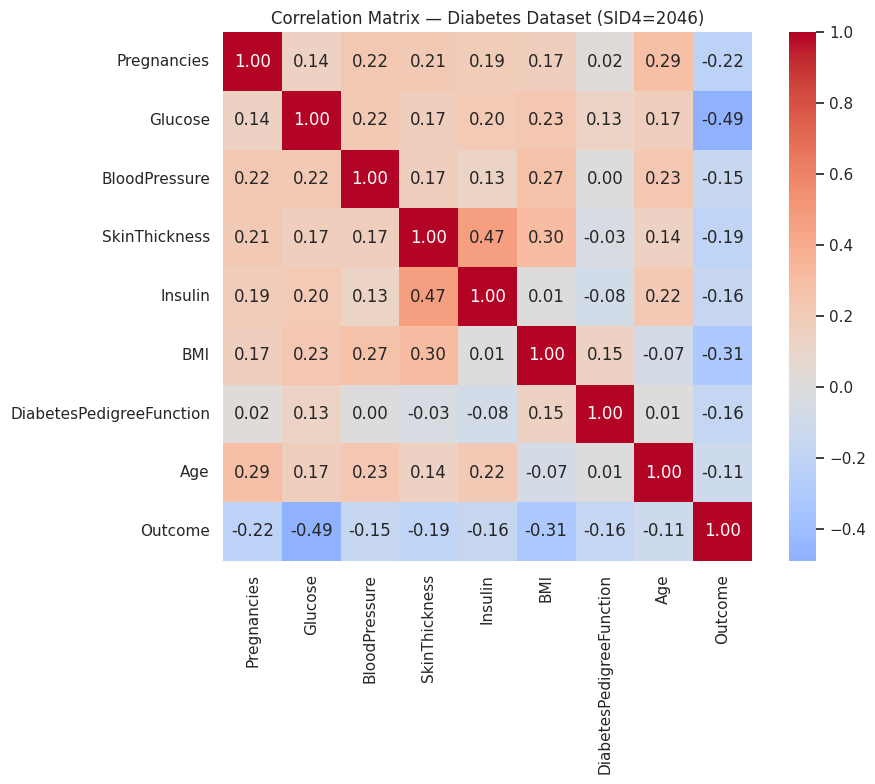

In [4]:
sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", center=0, square=True, cmap="coolwarm")
plt.title("Correlation Matrix — Diabetes Dataset (SID4=2046)")
plt.tight_layout()
plt.savefig(FIGURES / "correlation_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

log("NEURAL NETWORK SECTION", "Saved figures/correlation_matrix.png")

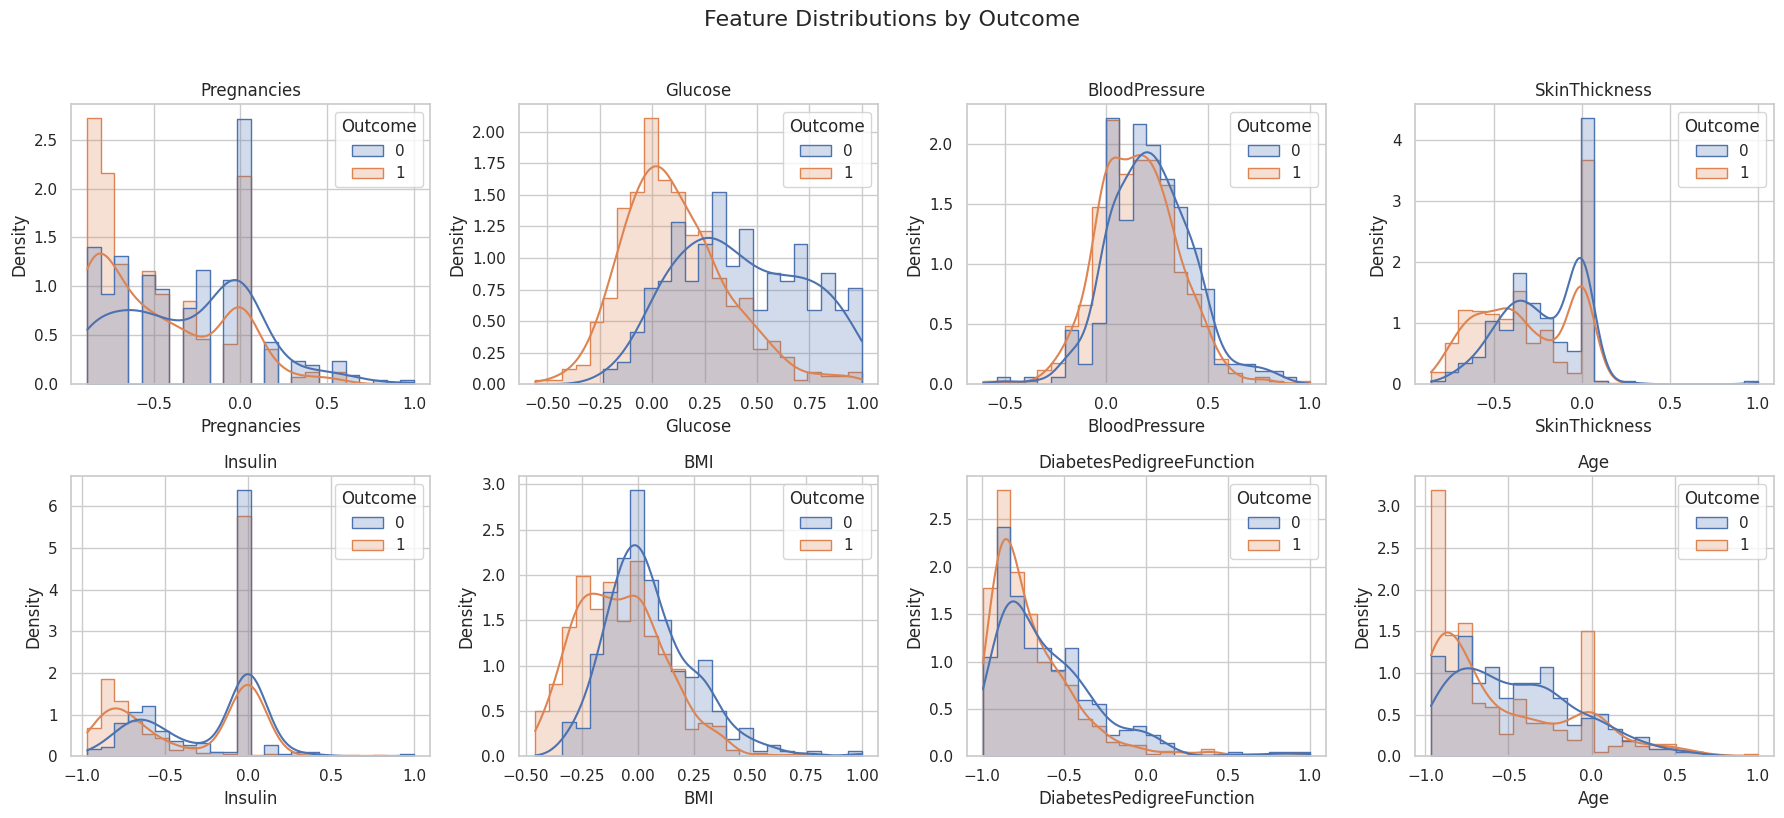

In [5]:
feature_columns = columns[:-1]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for feature, ax in zip(feature_columns, axes.flat):
    sns.histplot(data=df, x=feature, hue="Outcome", bins=24, kde=True,
                 stat="density", common_norm=False, element="step", ax=ax)
    ax.set_title(feature)
fig.suptitle("Feature Distributions by Outcome", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / "feature_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

log("NEURAL NETWORK SECTION", "Saved figures/feature_distributions.png")

In [6]:
X = df[feature_columns].to_numpy(dtype=np.float32)
y = df["Outcome"].to_numpy(dtype=np.float32)

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

split_summary = pd.DataFrame({
    "Subset": ["Training", "Validation", "Testing"],
    "Rows": [len(y_train), len(y_val), len(y_test)],
    "Percent of total": [len(y_train) / len(y), len(y_val) / len(y), len(y_test) / len(y)],
    "Positive rate": [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_summary.style.format({"Percent of total": "{:.1%}", "Positive rate": "{:.3f}"}))

assert len(y_train) + len(y_val) + len(y_test) == len(df)
log("NEURAL NETWORK SECTION", f"Split sizes: train={len(y_train)}, val={len(y_val)}, test={len(y_test)}")

,Subset,Rows,Percent of total,Positive rate
0,Training,531,70.0%,0.653
1,Validation,114,15.0%,0.658
2,Testing,114,15.0%,0.649


In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_val = scaler.transform(X_val_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

print("Scaler fitted on training data only.")
print("Training feature means (should be ~0):", X_train.mean(axis=0).round(3))
print("Training feature stds (should be ~1):", X_train.std(axis=0).round(3))

Scaler fitted on training data only.
Training feature means (should be ~0): [ 0.  0. -0. -0.  0. -0. -0. -0.]
Training feature stds (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


In [8]:
class TorchBinaryClassifier(nn.Module):
    def __init__(self, input_dim, hidden_layers):
        super().__init__()
        layers = []
        prev = input_dim
        for width in hidden_layers:
            layers += [nn.Linear(prev, width), nn.ReLU()]
            prev = width
        layers.append(nn.Linear(prev, 1))  # one raw output logit
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def train_torch(config, training_seed):
    random.seed(training_seed)
    np.random.seed(training_seed)
    torch.manual_seed(training_seed)
    torch.use_deterministic_algorithms(True, warn_only=True)

    model = TorchBinaryClassifier(X_train.shape[1], config["hidden_layers"])
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    criterion = nn.BCEWithLogitsLoss()

    train_x, train_y = torch.from_numpy(X_train), torch.from_numpy(y_train)
    val_x, val_y = torch.from_numpy(X_val), torch.from_numpy(y_val)
    test_x, test_y = torch.from_numpy(X_test), torch.from_numpy(y_test)

    generator = torch.Generator().manual_seed(training_seed)
    loader = DataLoader(TensorDataset(train_x, train_y), batch_size=config["batch_size"],
                         shuffle=True, generator=generator, num_workers=0)

    history = {"train_loss": [], "val_loss": []}
    for epoch in range(config["epochs"]):
        model.train()
        running = 0.0
        for bx, by in loader:
            optimizer.zero_grad(set_to_none=True)
            logits = model(bx)
            loss = criterion(logits, by)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(by)
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(val_x), val_y).item()
        history["train_loss"].append(running / len(train_y))
        history["val_loss"].append(val_loss)

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(test_x))
        preds = (probs >= 0.5).float()
        test_accuracy = (preds == test_y).float().mean().item()
    return test_accuracy, history


CONFIGS = [BASELINE_CONFIG, MODIFIED_CONFIG]

torch_rows = []
torch_histories = {}
for config in CONFIGS:
    for training_seed in TRAINING_SEEDS:
        acc, hist = train_torch(config, training_seed)
        torch_rows.append({"Framework": "PyTorch", "Model": config["name"],
                            "Training seed": training_seed, "Test accuracy": acc})
        if training_seed == SEED:
            torch_histories[config["name"]] = hist
        print(f"PyTorch | {config['name']:<20} | seed {training_seed} | test accuracy = {acc:.4f}")

torch_runs = pd.DataFrame(torch_rows)
display(torch_runs)
log("NEURAL NETWORK SECTION", "PyTorch runs:\n" + torch_runs.to_string(index=False))

PyTorch | Baseline             | seed 2046 | test accuracy = 0.7544
PyTorch | Baseline             | seed 2047 | test accuracy = 0.7281
PyTorch | Baseline             | seed 2048 | test accuracy = 0.7544
PyTorch | Modified (HP_ID 0)   | seed 2046 | test accuracy = 0.7456
PyTorch | Modified (HP_ID 0)   | seed 2047 | test accuracy = 0.7456
PyTorch | Modified (HP_ID 0)   | seed 2048 | test accuracy = 0.7544


,Framework,Model,Training seed,Test accuracy
0,PyTorch,Baseline,2046,0.754386
1,PyTorch,Baseline,2047,0.728070
2,PyTorch,Baseline,2048,0.754386
3,PyTorch,Modified (HP_ID 0),2046,0.745614
4,PyTorch,Modified (HP_ID 0),2047,0.745614
5,PyTorch,Modified (HP_ID 0),2048,0.754386


In [9]:
def build_tf_model(config, training_seed):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(training_seed)
    inputs = tf.keras.layers.Input(shape=(X_train.shape[1],))
    x = inputs
    for width in config["hidden_layers"]:
        x = tf.keras.layers.Dense(width, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1)(x)  # one raw output logit
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config["learning_rate"]),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5)],
    )
    return model


def train_tensorflow(config, training_seed):
    random.seed(training_seed)
    np.random.seed(training_seed)
    tf.keras.utils.set_random_seed(training_seed)
    model = build_tf_model(config, training_seed)
    fit_history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=config["epochs"], batch_size=config["batch_size"],
        shuffle=True, verbose=0,
    )
    logits = model.predict(X_test, verbose=0).squeeze(-1)
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(np.float32)
    test_accuracy = float((preds == y_test).mean())
    history = {
        "train_loss": list(map(float, fit_history.history["loss"])),
        "val_loss": list(map(float, fit_history.history["val_loss"])),
    }
    return test_accuracy, history


tensorflow_rows = []
tensorflow_histories = {}
for config in CONFIGS:
    for training_seed in TRAINING_SEEDS:
        acc, hist = train_tensorflow(config, training_seed)
        tensorflow_rows.append({"Framework": "TensorFlow", "Model": config["name"],
                                 "Training seed": training_seed, "Test accuracy": acc})
        if training_seed == SEED:
            tensorflow_histories[config["name"]] = hist
        print(f"TensorFlow | {config['name']:<20} | seed {training_seed} | test accuracy = {acc:.4f}")

tensorflow_runs = pd.DataFrame(tensorflow_rows)
display(tensorflow_runs)
log("NEURAL NETWORK SECTION", "TensorFlow runs:\n" + tensorflow_runs.to_string(index=False))

TensorFlow | Baseline             | seed 2046 | test accuracy = 0.7281
TensorFlow | Baseline             | seed 2047 | test accuracy = 0.7368


TensorFlow | Baseline             | seed 2048 | test accuracy = 0.7281
TensorFlow | Modified (HP_ID 0)   | seed 2046 | test accuracy = 0.7632
TensorFlow | Modified (HP_ID 0)   | seed 2047 | test accuracy = 0.7368
TensorFlow | Modified (HP_ID 0)   | seed 2048 | test accuracy = 0.7544


,Framework,Model,Training seed,Test accuracy
0,TensorFlow,Baseline,2046,0.728070
1,TensorFlow,Baseline,2047,0.736842
2,TensorFlow,Baseline,2048,0.728070
3,TensorFlow,Modified (HP_ID 0),2046,0.763158
4,TensorFlow,Modified (HP_ID 0),2047,0.736842
5,TensorFlow,Modified (HP_ID 0),2048,0.754386


In [10]:
all_runs = pd.concat([torch_runs, tensorflow_runs], ignore_index=True)
all_runs.to_csv("neural_metrics.csv", index=False)
display(all_runs)

summary = (
    all_runs.groupby(["Framework", "Model"])["Test accuracy"]
    .agg(["mean", "std"]).reset_index()
    .rename(columns={"mean": "Mean test accuracy", "std": "Std dev (sample, n=3)"})
)
display(summary.style.format({"Mean test accuracy": "{:.4f}", "Std dev (sample, n=3)": "{:.4f}"}))

log("NEURAL NETWORK SECTION", "Summary:\n" + summary.to_string(index=False))

,Framework,Model,Training seed,Test accuracy
0,PyTorch,Baseline,2046,0.754386
1,PyTorch,Baseline,2047,0.728070
2,PyTorch,Baseline,2048,0.754386
3,PyTorch,Modified (HP_ID 0),2046,0.745614
4,PyTorch,Modified (HP_ID 0),2047,0.745614
5,PyTorch,Modified (HP_ID 0),2048,0.754386
6,TensorFlow,Baseline,2046,0.728070
7,TensorFlow,Baseline,2047,0.736842
8,TensorFlow,Baseline,2048,0.728070
9,TensorFlow,Modified (HP_ID 0),2046,0.763158


,Framework,Model,Mean test accuracy,"Std dev (sample, n=3)"
0,PyTorch,Baseline,0.7456,0.0152
1,PyTorch,Modified (HP_ID 0),0.7485,0.0051
2,TensorFlow,Baseline,0.7310,0.0051
3,TensorFlow,Modified (HP_ID 0),0.7515,0.0134


In [11]:
def loss_diagnostics(history):
    val_loss = history["val_loss"]
    train_loss = history["train_loss"]
    best_epoch = int(np.argmin(val_loss)) + 1  # 1-indexed
    return {
        "Best validation epoch": best_epoch,
        "Minimum validation loss": min(val_loss),
        "Final training loss": train_loss[-1],
        "Final validation loss": val_loss[-1],
    }

diagnostics_rows = []
for framework, histories in [("PyTorch", torch_histories), ("TensorFlow", tensorflow_histories)]:
    for model_name, history in histories.items():
        d = loss_diagnostics(history)
        d["Framework"] = framework
        d["Model"] = model_name
        diagnostics_rows.append(d)

diagnostics = pd.DataFrame(diagnostics_rows)[
    ["Framework", "Model", "Best validation epoch", "Minimum validation loss",
     "Final training loss", "Final validation loss"]
]
display(diagnostics.style.format({
    "Minimum validation loss": "{:.4f}", "Final training loss": "{:.4f}", "Final validation loss": "{:.4f}"
}))

log("NEURAL NETWORK SECTION", "Loss diagnostics (seed 2046 runs):\n" + diagnostics.to_string(index=False))

,Framework,Model,Best validation epoch,Minimum validation loss,Final training loss,Final validation loss
0,PyTorch,Baseline,19,0.4778,0.3857,0.4829
1,PyTorch,Modified (HP_ID 0),29,0.5000,0.4304,0.5015
2,TensorFlow,Baseline,28,0.4954,0.3652,0.4961
3,TensorFlow,Modified (HP_ID 0),20,0.5003,0.4155,0.5017


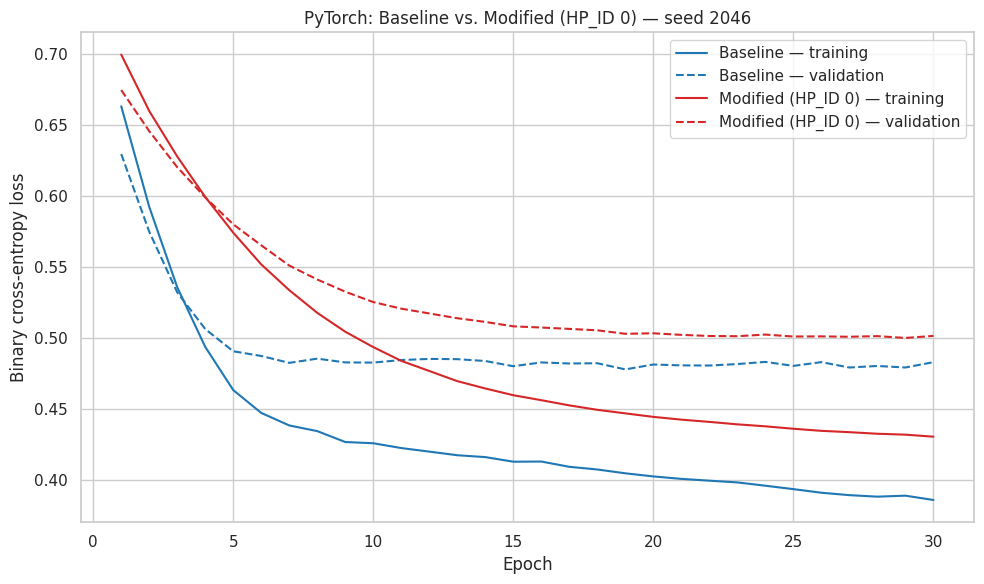

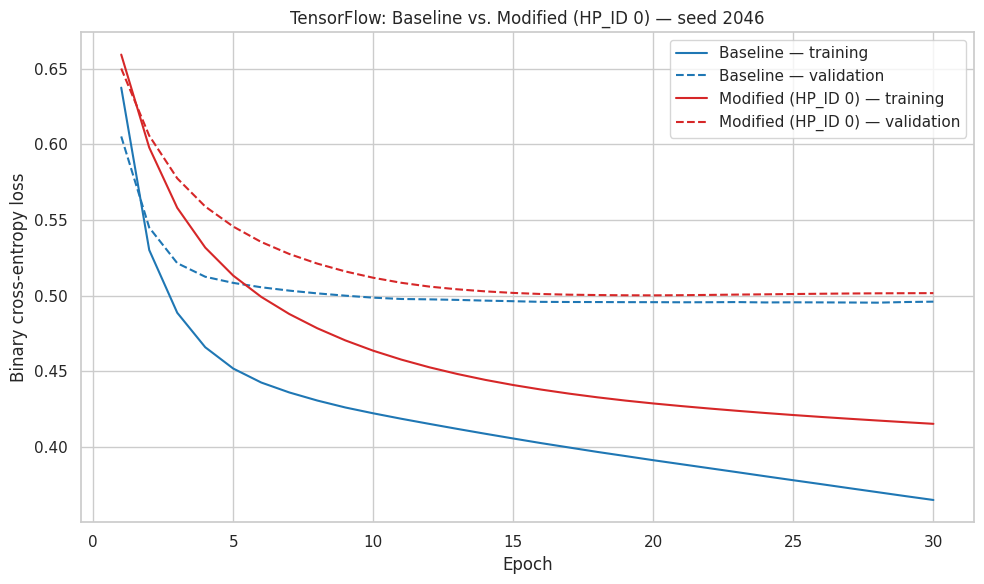

In [12]:
def plot_losses(framework, histories, filename):
    plt.figure(figsize=(10, 6))
    colors = {BASELINE_CONFIG["name"]: "#1f77b4", MODIFIED_CONFIG["name"]: "#d62728"}
    for model_name, history in histories.items():
        epochs = np.arange(1, len(history["train_loss"]) + 1)
        plt.plot(epochs, history["train_loss"], color=colors[model_name], linestyle="-",
                  label=f"{model_name} — training")
        plt.plot(epochs, history["val_loss"], color=colors[model_name], linestyle="--",
                  label=f"{model_name} — validation")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy loss")
    plt.title(f"{framework}: Baseline vs. Modified (HP_ID 0) — seed {SEED}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES / filename, dpi=180, bbox_inches="tight")
    plt.show()

plot_losses("PyTorch", torch_histories, "pytorch_loss_curves.png")
plot_losses("TensorFlow", tensorflow_histories, "tensorflow_loss_curves.png")

Path("loss_histories.json").write_text(
    json.dumps({"PyTorch": torch_histories, "TensorFlow": tensorflow_histories}, indent=2),
    encoding="utf-8"
)
log("NEURAL NETWORK SECTION", "Saved pytorch_loss_curves.png, tensorflow_loss_curves.png, loss_histories.json")

In [13]:
expected_pairs = {(fw, m) for fw in ["PyTorch", "TensorFlow"] for m in [BASELINE_CONFIG["name"], MODIFIED_CONFIG["name"]]}
observed_pairs = set(map(tuple, all_runs[["Framework", "Model"]].drop_duplicates().to_numpy()))
assert observed_pairs == expected_pairs
assert all_runs.groupby(["Framework", "Model"]).size().eq(3).all()
assert all_runs["Test accuracy"].between(0, 1).all()
assert len(torch_histories[BASELINE_CONFIG["name"]]["train_loss"]) == BASELINE_CONFIG["epochs"]
assert len(tensorflow_histories[MODIFIED_CONFIG["name"]]["val_loss"]) == MODIFIED_CONFIG["epochs"]
assert all((FIGURES / name).exists() for name in [
    "correlation_matrix.png", "feature_distributions.png",
    "pytorch_loss_curves.png", "tensorflow_loss_curves.png"
])
print("All neural-network notebook checks passed.")
log("NEURAL NETWORK SECTION END", "All verification checks passed.")

All neural-network notebook checks passed.
